<a href="https://colab.research.google.com/github/spierro01/Electron-proton-classifier/blob/main/electron_proton_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier


Mounted at /content/drive


In [2]:
# prendo tutti i file degli elettroni e protoni
files_e = glob.glob("/content/drive/MyDrive/H5_FILES/electron__FTFP_BERT/*.pkl")
files_p = glob.glob("/content/drive/MyDrive/H5_FILES/proton__FTFP_BERT/*.pkl")

# carico e unisco tutti i file degli elettroni
df_electron = pd.concat(
    [pd.read_pickle(f) for f in files_e],
    ignore_index=True
)

# carico e unisco tutti i file dei protoni
df_proton = pd.concat(
    [pd.read_pickle(f) for f in files_p],
    ignore_index=True
)

In [3]:
# assegno le etichette: 0 = elettrone, 1 = protone
df_electron["label"] = 0
df_proton["label"] = 1

In [4]:
# unisco tutto in un unico dataset
df_all = pd.concat([df_electron, df_proton], ignore_index=True)

In [5]:
# colonne TR1
tr1_cols = [c for c in df_all.columns if "TR1" in c and "PMT_ADC_HG" in c]

# colonne TR2
tr2_cols = [c for c in df_all.columns if "TR2" in c and "PMT_ADC_HG" in c]

# colonne RAN
ran_cols = [c for c in df_all.columns if "RAN" in c and "PMT_ADC_HG" in c]

# creo le somme separate
df_all["TR1_sum"] = df_all[tr1_cols].sum(axis=1)
df_all["TR2_sum"] = df_all[tr2_cols].sum(axis=1)
df_all["RAN_sum"] = df_all[ran_cols].sum(axis=1)

en1_cols = [c for c in df_all.columns if "EN1" in c and "PMT_ADC_HG" in c]
en2_cols = [c for c in df_all.columns if "EN2" in c and "PMT_ADC_HG" in c]

# colonne dei segnali EN1 e EN2
en1_cols = [c for c in df_all.columns if "EN1" in c and "PMT_ADC_HG" in c]
en2_cols = [c for c in df_all.columns if "EN2" in c and "PMT_ADC_HG" in c]

# somma segnali per ogni layer
df_all["EN1_sum"] = df_all[en1_cols].sum(axis=1)
df_all["EN2_sum"] = df_all[en2_cols].sum(axis=1)

# energia totale nella sezione EN
df_all["EN_total"] = df_all["EN1_sum"] + df_all["EN2_sum"]

In [6]:
# scelgo le feature per il modello
features = [
    "TR1_sum",
    "TR2_sum",
    "RAN_sum",
    "EN_total",
    "phi",
    "theta",
    "csize1",
    "csize2",
    "csize3",
    "cls_res_x1",
    "cls_res_y1",
    "cls_res_x2",
    "cls_res_y2",
    "cls_res_x3",
    "cls_res_y3",
]

# matrice input (X) e target (y)
X = df_all[features] #input
y = df_all["label"] #target

In [7]:
# split: 80% train+val, 20% test finale
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)



In [8]:
# creo modello Random Forest
model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

# addestramento modello
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=400,
                       random_state=42)

In [9]:
# probabilità di essere protone sul validation set
y_val_prob = model.predict_proba(X_val)[:, 1]

from sklearn.metrics import accuracy_score

# inizializzo ricerca soglia ottimale
best_t = 0.5
best_score = 0

# provo 100 soglie diverse tra 0 e 1
for t in np.linspace(0, 1, 100):
    y_val_pred = (y_val_prob > t).astype(int)  # trasformo probabilità in classe (0/1)
    score = accuracy_score(y_val, y_val_pred)  # calcolo accuracy

    if score > best_score:
        best_score = score
        best_t = t #miglior soglia che separa elettroni e protoni

print("Best threshold:", best_t)
print("Best validation accuracy:", best_score)

Best threshold: 0.5252525252525253
Best validation accuracy: 0.8192228603843154


In [10]:
# predizione finale sul test set
y_test_prob = model.predict_proba(X_test)[:, 1]

# applico soglia ottimale
y_test_pred = (y_test_prob > best_t).astype(int)

In [11]:
#metriche
print(confusion_matrix(y_test, y_test_pred))
print("AUC:", roc_auc_score(y_test, y_test_prob))

[[ 8617  2689]
 [ 2525 14375]]
AUC: 0.9032384935683728


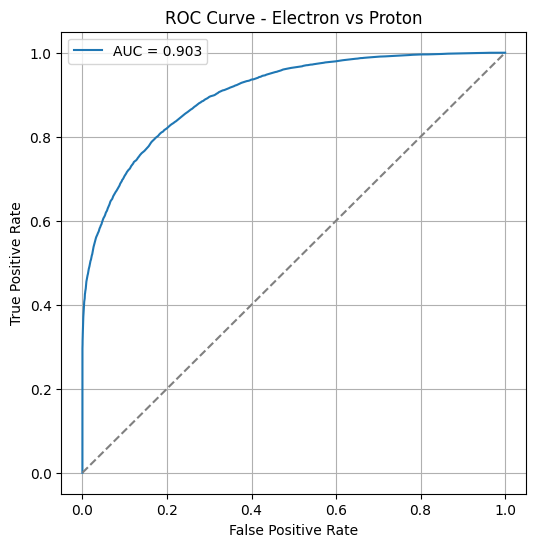

In [12]:
# probabilità finali classe positiva (protoni)
y_prob = model.predict_proba(X_test)[:, 1]

# curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Electron vs Proton")
plt.legend()
plt.grid()
plt.show()